In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk


In [3]:
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Nikhil\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nikhil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nikhil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
from nltk.corpus import movie_reviews

reviews = []
sentiments = []

for fileid in movie_reviews.fileids():
    reviews.append(movie_reviews.raw(fileid))
    sentiments.append(movie_reviews.categories(fileid)[0])

df = pd.DataFrame({
    "review": reviews,
    "sentiment": sentiments
})

df.head()

,review,sentiment
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


In [5]:
df['sentiment']=df['sentiment'].map({
    'pos':1,
    'neg':0
})
df.head()

,review,sentiment
0,"plot : two teen couples go to a church party ,...",0
1,the happy bastard's quick movie review \ndamn ...,0
2,it is movies like these that make a jaded movi...,0
3,""" quest for camelot "" is warner bros . ' firs...",0
4,synopsis : a mentally unstable man undergoing ...,0


In [7]:
from nltk.corpus import stopwords

# load stopwords once
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # 1. convert to lowercase
    text = text.lower()

    # 2. remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # 3. split text into words
    words = text.split()

    # 4. remove stopwords
    words = [word for word in words if word not in stop_words]

    # 5. join words back into sentence
    return " ".join(words)

# apply cleaning function
df['cleaned_review'] = df['review'].apply(clean_text)

df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,"plot : two teen couples go to a church party ,...",plot two teen couples go church party drink dr...
1,the happy bastard's quick movie review \ndamn ...,happy bastard quick movie review damn k bug go...
2,it is movies like these that make a jaded movi...,movies like make jaded movie viewer thankful i...
3,""" quest for camelot "" is warner bros . ' firs...",quest camelot warner bros first feature length...
4,synopsis : a mentally unstable man undergoing ...,synopsis mentally unstable man undergoing psyc...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# create TF-IDF object
vectorizer = TfidfVectorizer(max_features=3000)

# convert text into numerical vectors
X = vectorizer.fit_transform(df['cleaned_review'])

# target column
y = df['sentiment']

print(X.shape)

(2000, 3000)


In [10]:
from sklearn.model_selection import train_test_split

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 3000)
Testing Data Shape: (400, 3000)


In [11]:
from sklearn.linear_model import LogisticRegression

# create model
model = LogisticRegression(max_iter=1000)

# train model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
from sklearn.metrics import accuracy_score

# make predictions
y_pred = model.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.825


In [16]:
from sklearn.metrics import confusion_matrix

# create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[164  35]
 [ 35 166]]


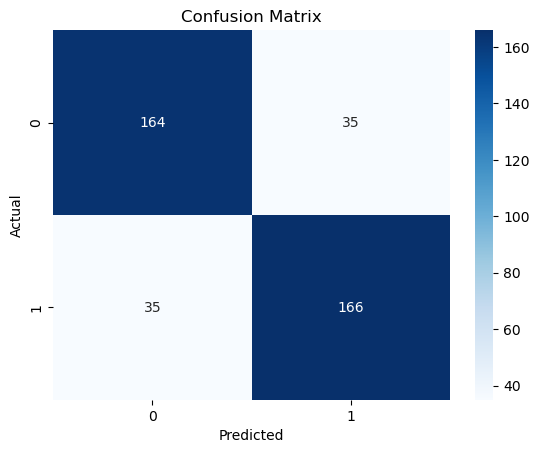

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [18]:
def predict_sentiment(text):

    # clean the text
    cleaned = clean_text(text)

    # convert into TF-IDF vector
    vector = vectorizer.transform([cleaned])

    # predict sentiment
    prediction = model.predict(vector)[0]

    # convert number into label
    if prediction == 1:
        return "Positive 😊"
    else:
        return "Negative 😡"


# take user input
user_review = input("Enter a movie review: ")

# get prediction
result = predict_sentiment(user_review)

print("Predicted Sentiment:", result)

Predicted Sentiment: Positive 😊


In [19]:
import pickle

# save model
with open("sentiment_model.pkl", "wb") as file:
    pickle.dump(model, file)

# save vectorizer
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
